# NoteBook Classificação - Risco de Obesidade

Romain SEBIRE - 125 009 460

## Carregamento e verificação dos dados ##


In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

# Exibição das primeiras linhas
df_train.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [89]:
#Estatísticas sobre os dados numéricos
df_train.describe(include='all')

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
count,20758.00000,20758,20758.000000,20758.000000,20758.000000,20758,20758,20758.000000,20758.000000,20758,20758,20758.000000,20758,20758.000000,20758.000000,20758,20758,20758
unique,NaN,2,NaN,NaN,NaN,2,2,NaN,NaN,4,2,NaN,2,NaN,NaN,3,5,7
top,NaN,Female,NaN,NaN,NaN,yes,yes,NaN,NaN,Sometimes,no,NaN,no,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_III
freq,NaN,10422,NaN,NaN,NaN,17014,18982,NaN,NaN,17529,20513,NaN,20071,NaN,NaN,15066,16687,4046
mean,10378.50000,NaN,23.841804,1.700245,87.887768,NaN,NaN,2.445908,2.761332,NaN,NaN,2.029418,NaN,0.981747,0.616756,NaN,NaN,NaN
std,5992.46278,NaN,5.688072,0.087312,26.379443,NaN,NaN,0.533218,0.705375,NaN,NaN,0.608467,NaN,0.838302,0.602113,NaN,NaN,NaN
min,0.00000,NaN,14.000000,1.450000,39.000000,NaN,NaN,1.000000,1.000000,NaN,NaN,1.000000,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,5189.25000,NaN,20.000000,1.631856,66.000000,NaN,NaN,2.000000,3.000000,NaN,NaN,1.792022,NaN,0.008013,0.000000,NaN,NaN,NaN
50%,10378.50000,NaN,22.815416,1.700000,84.064875,NaN,NaN,2.393837,3.000000,NaN,NaN,2.000000,NaN,1.000000,0.573887,NaN,NaN,NaN
75%,15567.75000,NaN,26.000000,1.762887,111.600553,NaN,NaN,3.000000,3.000000,NaN,NaN,2.549617,NaN,1.587406,1.000000,NaN,NaN,NaN


In [90]:
# Verificação de dados ausentes
missing_values_train = df_train.isnull().sum()
print("Missing values in train dataset:\n", missing_values_train)

missing_values_test = df_test.isnull().sum()
print("Missing values in test dataset:\n", missing_values_test)

Missing values in train dataset:
 id                                0
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64
Missing values in test dataset:
 id                                0
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                

Não há valores ausentes nem nos dados de treino nem nos dados de teste.

In [91]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  object 
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  object 
 6   FAVC                            20758 non-null  object 
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  object 
 10  SMOKE                           20758 non-null  object 
 11  CH2O                            20758 non-null  float64
 12  SCC                             

### Notas sobre as variáveis explicativas

Dados numéricos: Age, Height, Weight, FCVC, NCP, CH2O, FAF, TUE

Dados categóricos: Gender, histórico familiar de sobrepeso, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS

#### Significado de cada variável

id — Identificador único da linha

Gender — Sexo do indivíduo (Male ou Female)

Age — Idade em anos

Height — Altura em metros

Weight — Peso em quilogramas

family\_history\_with\_overweight — Há histórico familiar de sobrepeso? (yes ou no)

FAVC — Consumo frequente de alimentos muito calóricos (yes ou no)

FCVC — Frequência de consumo de vegetais (em uma escala, geralmente 1 a 3)

NCP — Número de refeições principais por dia (geralmente 1 a 4)

CAEC — Consumo de alimentos entre as refeições: no, Sometimes, Frequently, Always

SMOKE — Fumante? (yes ou no)

CH2O — Litros de água consumidos por dia (geralmente entre 0 e 3)

SCC — Monitora o consumo calórico? (yes ou no)

FAF — Frequência de atividade física (de 0 = nunca até 3 = diariamente)

TUE — Tempo usando tecnologia por dia (em horas)

CALC — Consumo de álcool: no, Sometimes, Frequently, Always

MTRANS — Meio de transporte principal: Public\_Transportation, Walking, Automobile, etc.

NObeyesdad — Alvo: classe de corpulência (ex: Normal\_Weight, Obesity\_Type\_I, etc.)


## Análise exploratória dos dados (EDA)

### Visualização dos dados de treino

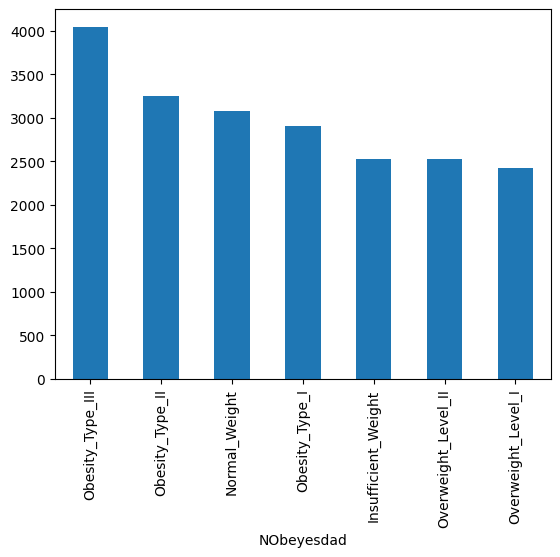

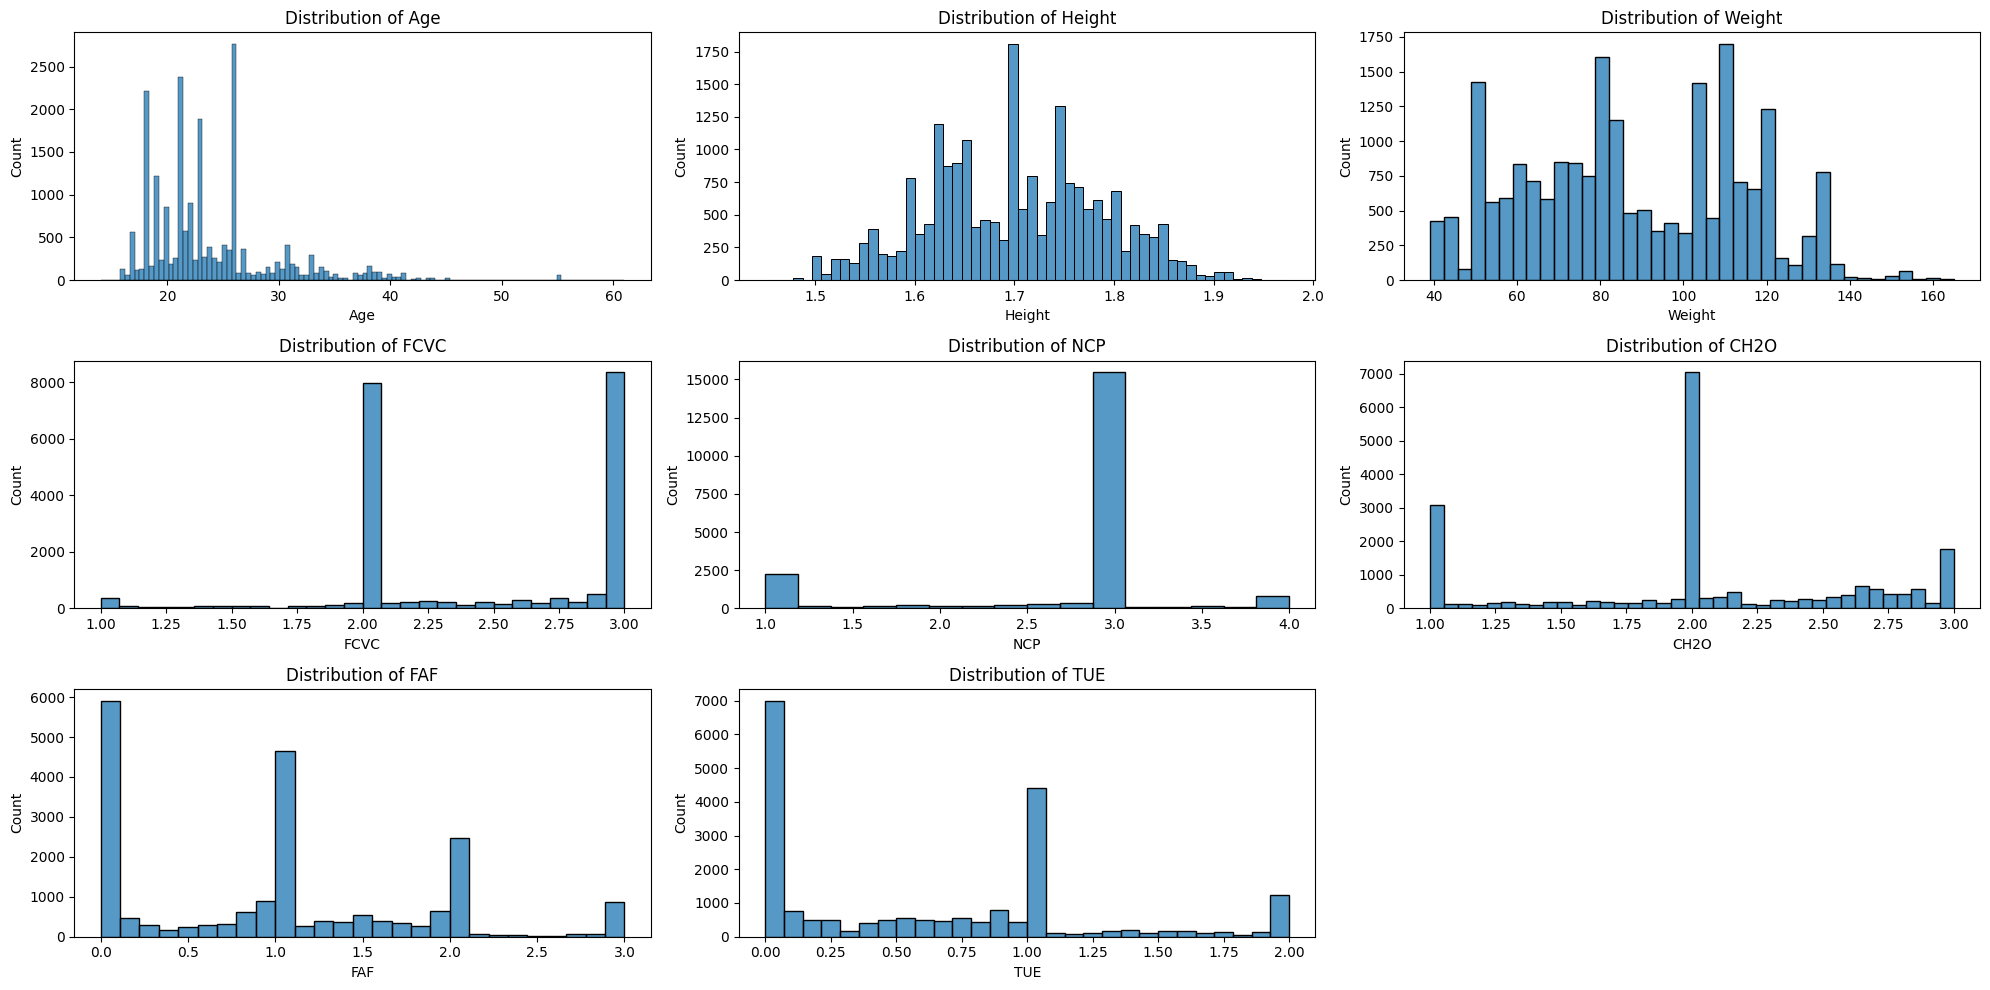

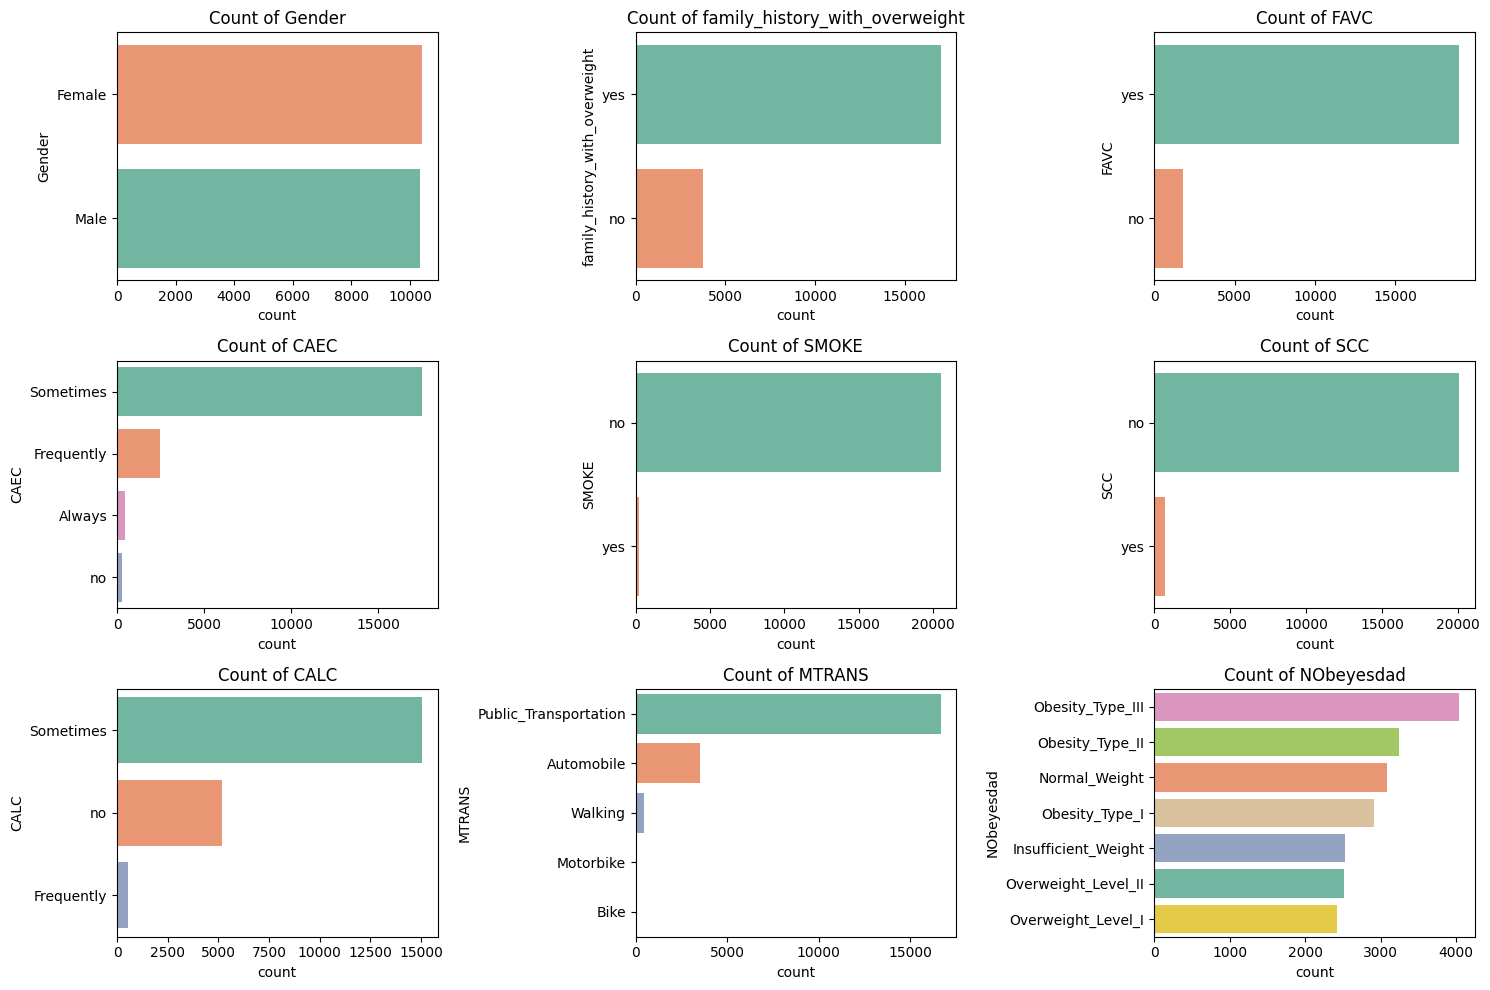

In [92]:
df = df_train.copy()

# Análise do alvo (target)
df['NObeyesdad'].value_counts().plot(kind='bar')

# Visualização da distribuição das variáveis numéricas por histograma
numeric_columns = df.select_dtypes(include=['float64']).columns

plt.figure(figsize=(20, 10))
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[column])
    plt.title(f'Distribution of {column}')
    plt.tight_layout()

plt.show()

# Contagem e visualização do número de dados das variáveis categóricas
category_columns = df.select_dtypes(include=['object']).columns

plt.figure(figsize=(15, 10))
for i, column in enumerate(category_columns, 1):
    plt.subplot(3, 3, i)
    sns.countplot(
        y=df[column], 
        order=df[column].value_counts().index,
        hue=df[column],
        palette="Set2",
        dodge=False,
        legend=False
    )
    plt.title(f'Count of {column}')
    plt.tight_layout()

plt.show()

Observa-se que não há indivíduos com CALC: Always nos dados de treino.

A classe Obesity\_Type\_III está ligeiramente sobrerrepresentada.

### Visualização dos dados de teste

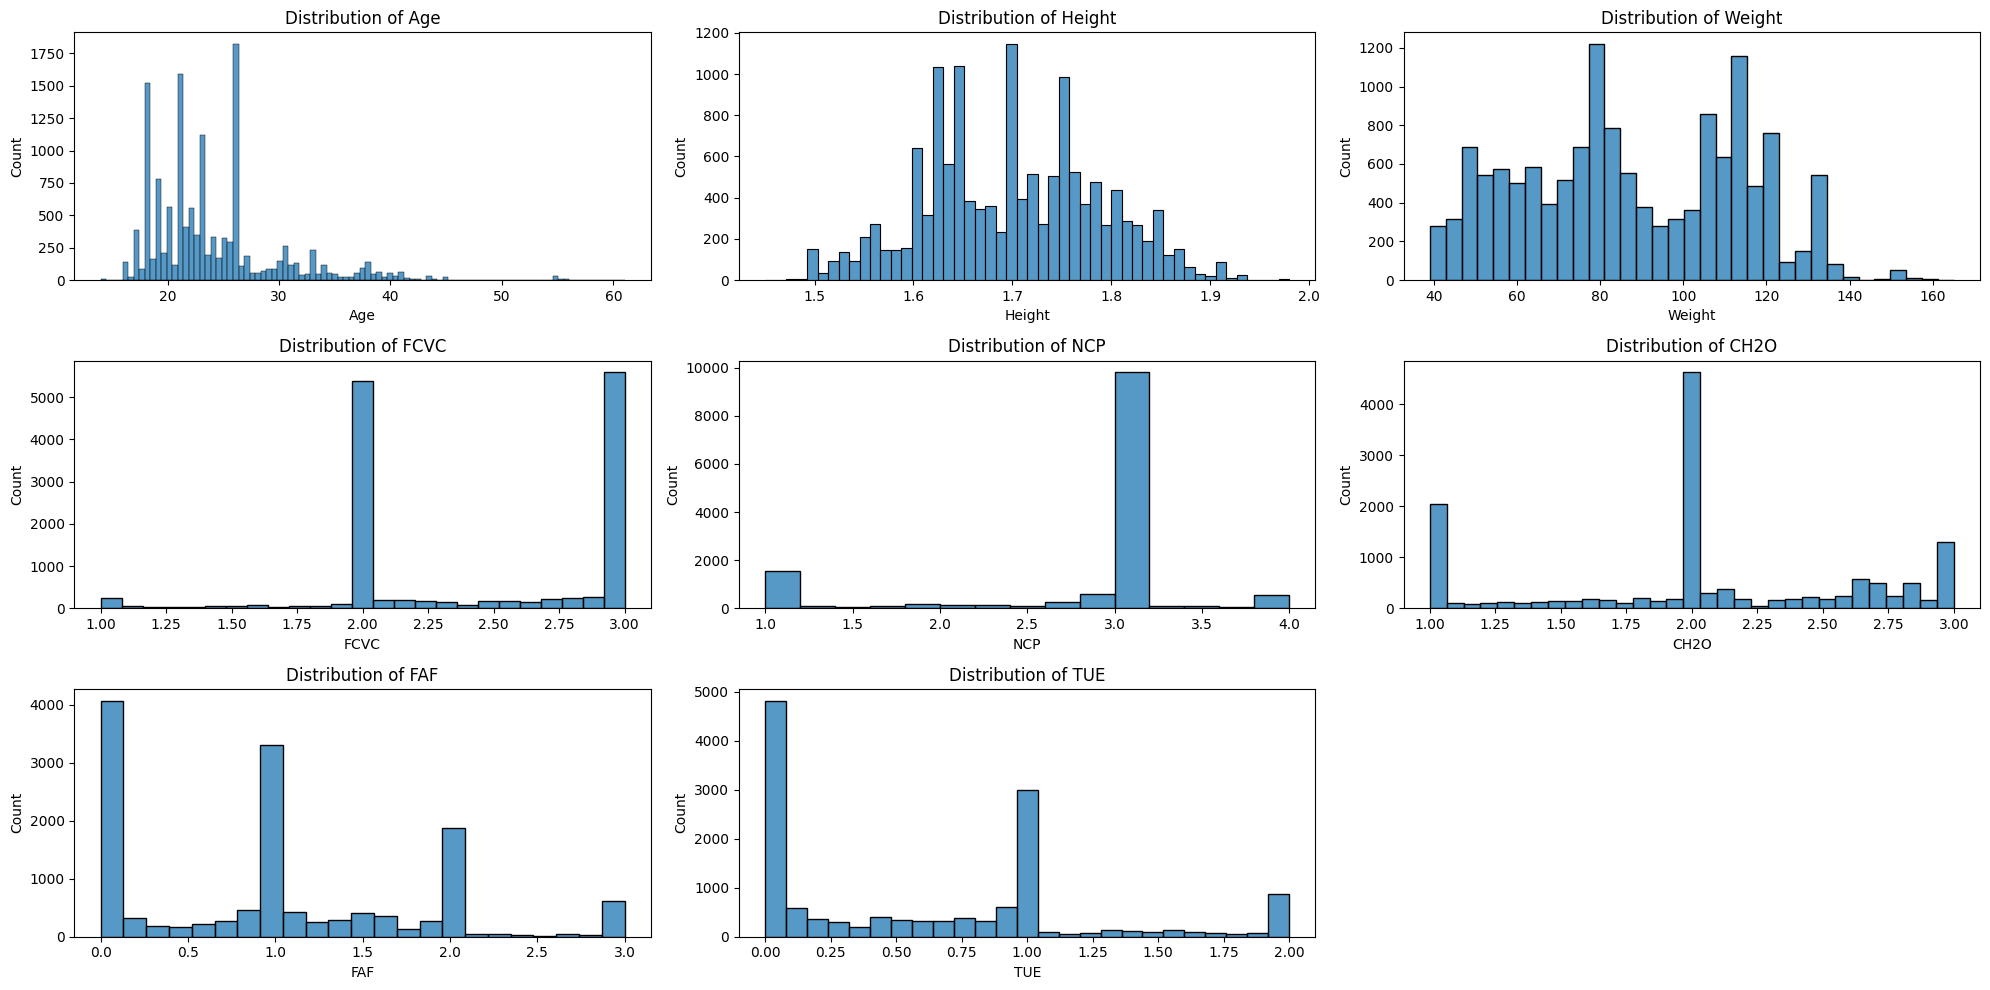

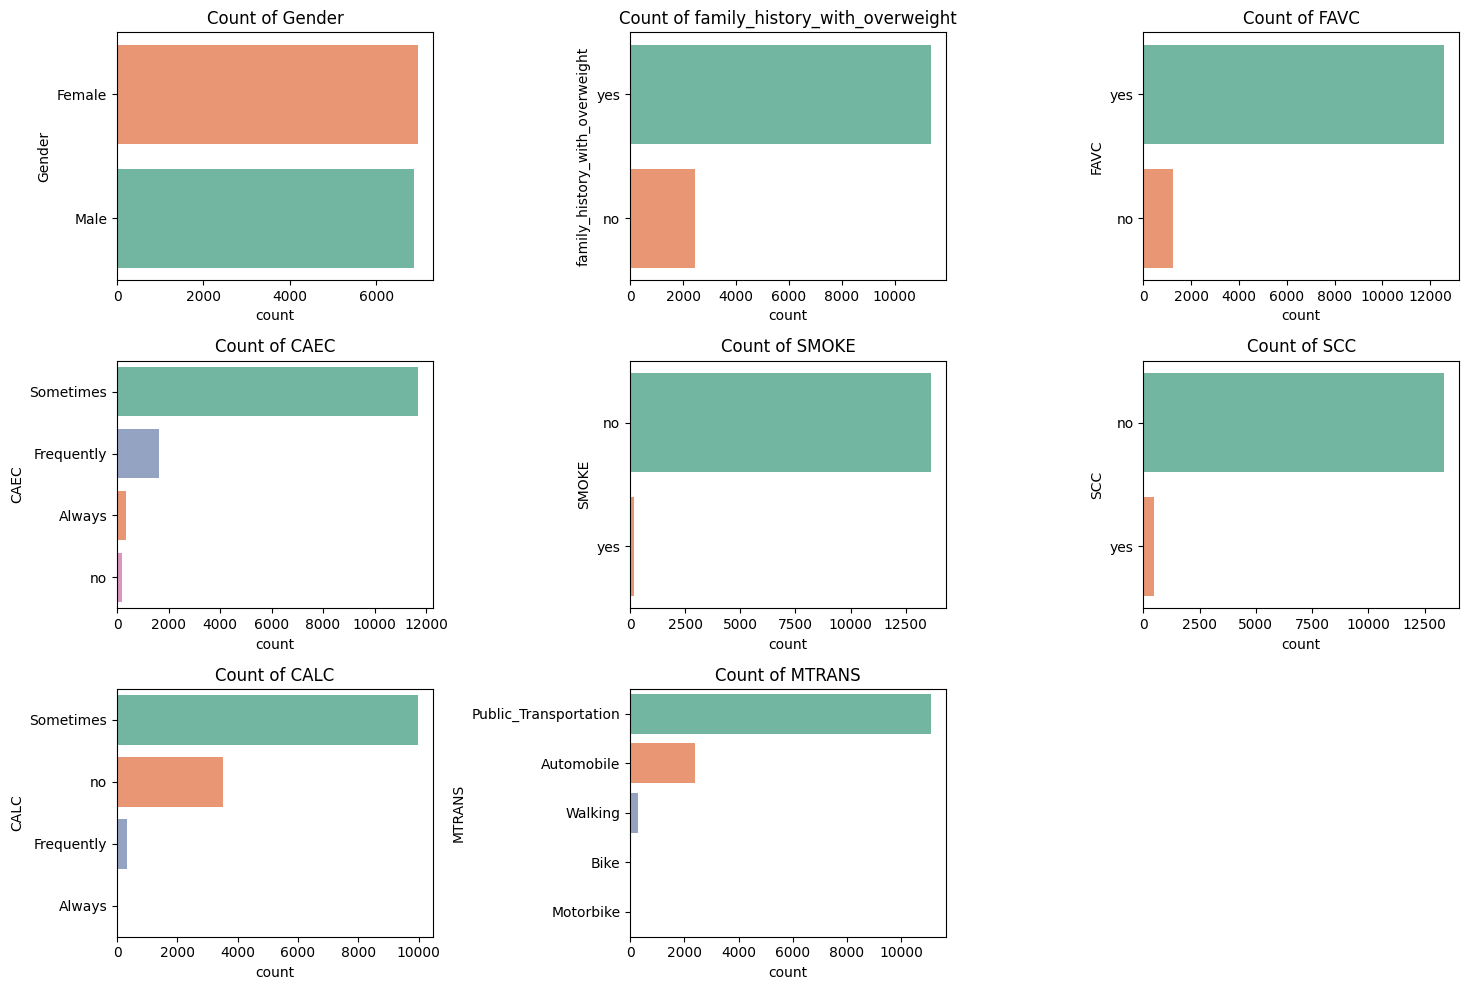

In [94]:
df = df_test.copy()

# Visualização da distribuição das variáveis numéricas por histograma
numeric_columns = df.select_dtypes(include=['float64']).columns

plt.figure(figsize=(20, 10))
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[column])
    plt.title(f'Distribution of {column}')
    plt.tight_layout()

plt.show()

# Contagem e visualização do número de dados das variáveis categóricas
category_columns = df.select_dtypes(include=['object']).columns

plt.figure(figsize=(15, 10))
for i, column in enumerate(category_columns, 1):
    plt.subplot(3, 3, i)
    sns.countplot(
        y=df[column], 
        order=df[column].value_counts().index,
        hue=df[column],
        palette="Set2",
        dodge=False,
        legend=False
    )
    plt.title(f'Count of {column}')
    plt.tight_layout()

plt.show()

### Visualização das relações com a variável alvo (NObeyesdad)

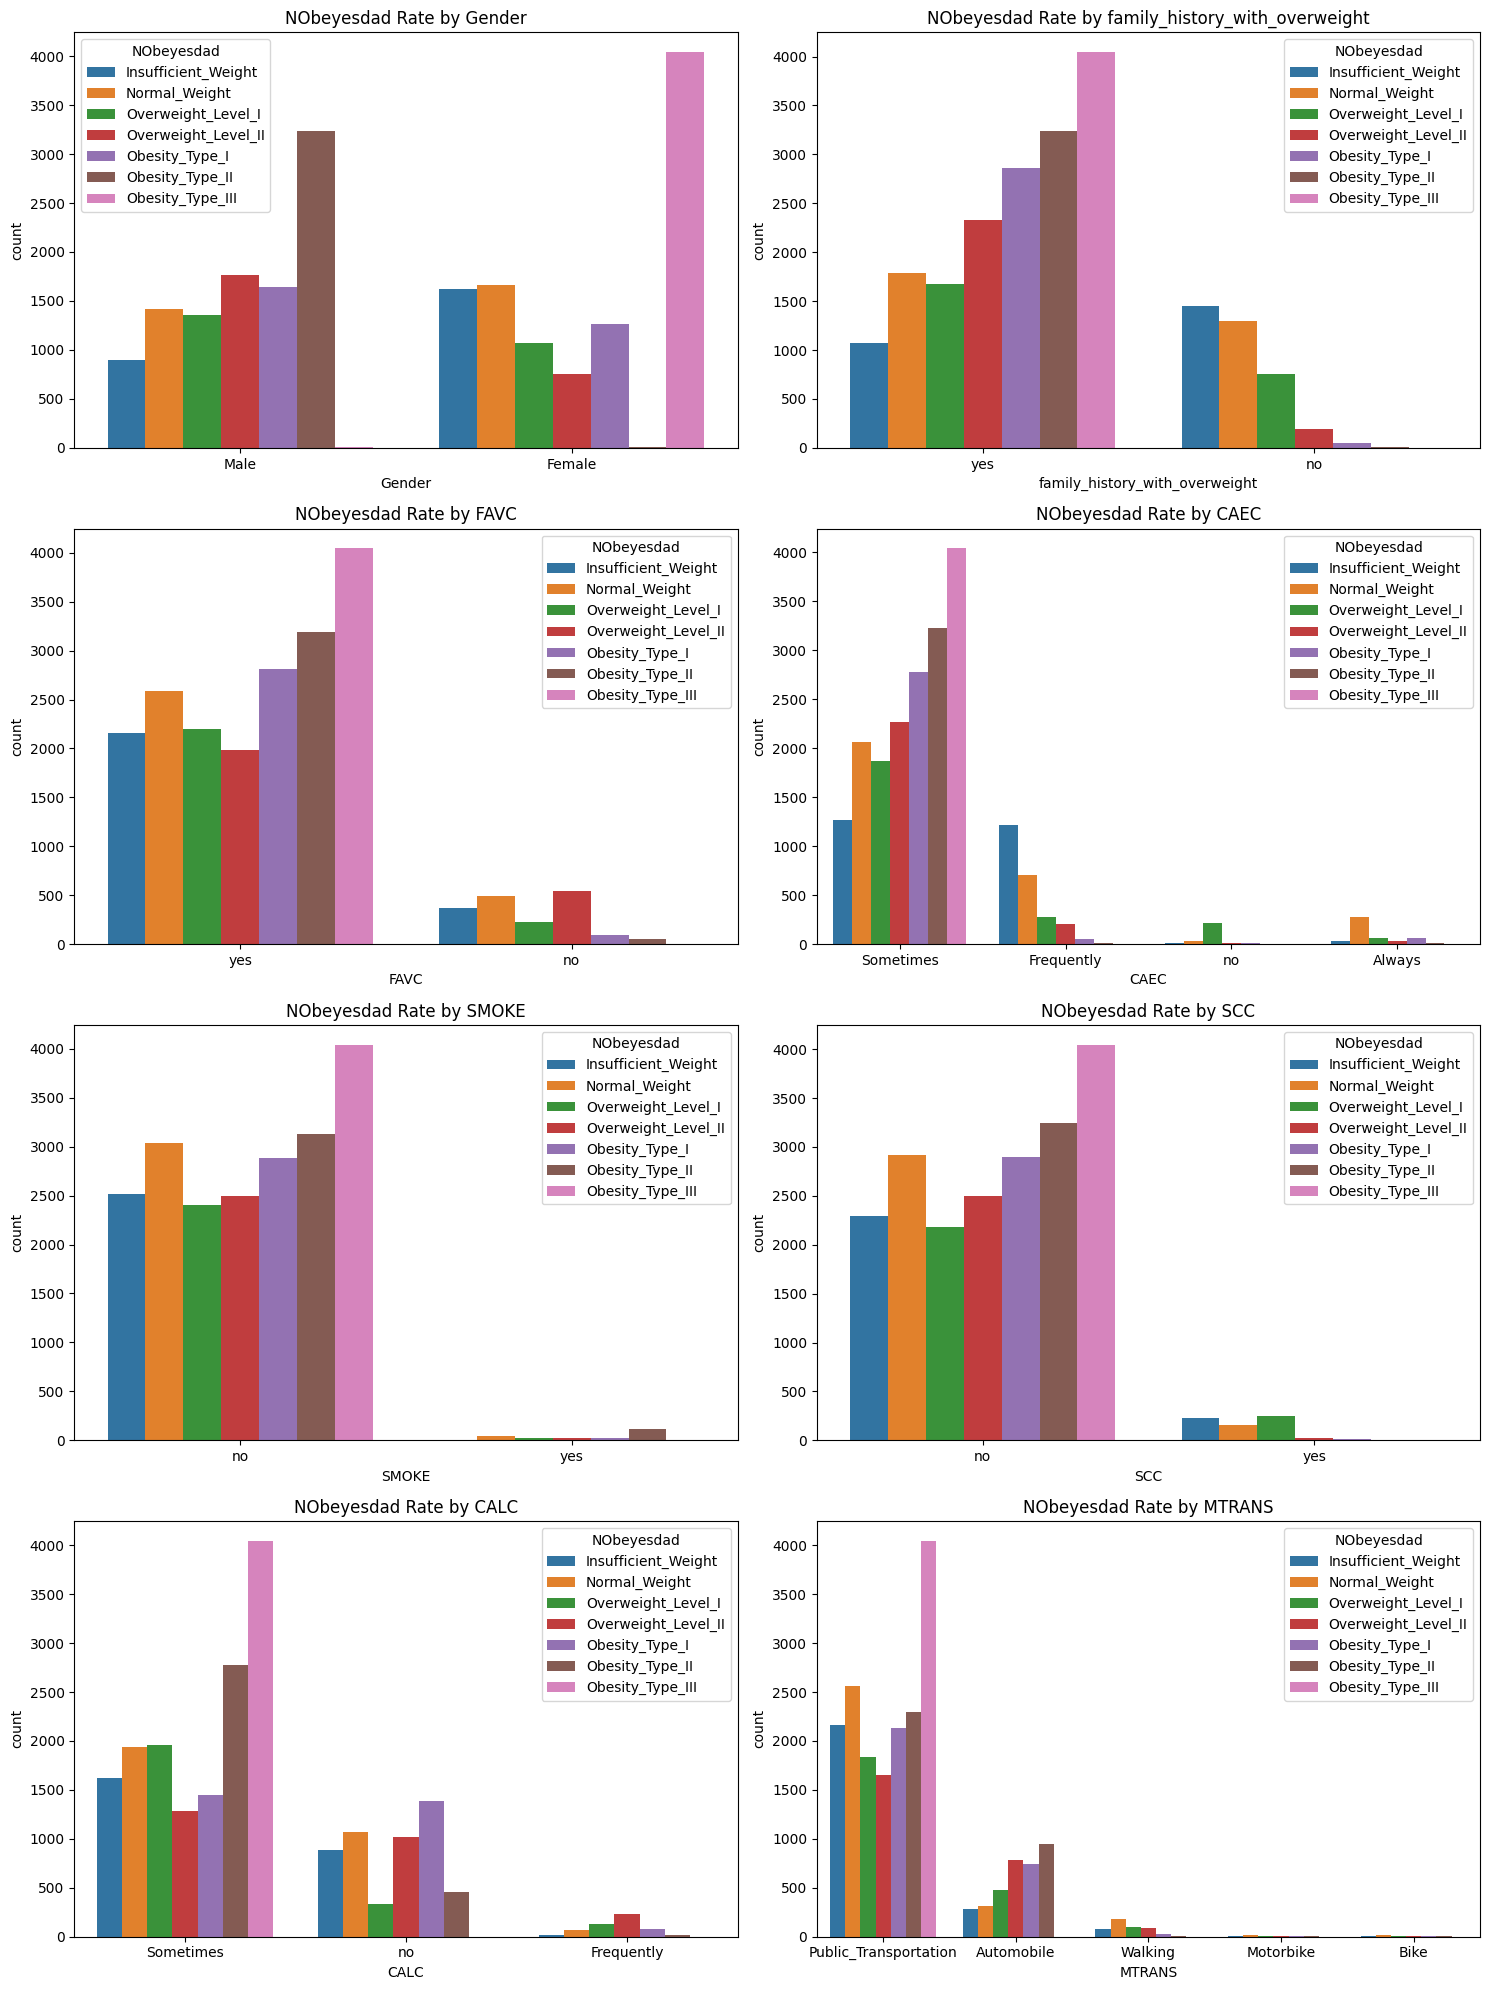

In [98]:
df = df_train.copy()

# Definição da ordem das variáveis categóricas
category_order = ['Insufficient_Weight','Normal_Weight',  'Overweight_Level_I', 'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

# Visualização das relações com os dados categóricos

plt.figure(figsize=(15, 20))

# Gender
plt.subplot(4, 2, 1)
sns.countplot(x='Gender', hue='NObeyesdad', data=df, hue_order=category_order)
plt.title('NObeyesdad Rate by Gender')

#family_history_with_overweight
plt.subplot(4, 2, 2)
sns.countplot(x='family_history_with_overweight', hue='NObeyesdad', data=df, hue_order=category_order)
plt.title('NObeyesdad Rate by family_history_with_overweight')

# FAVC
plt.subplot(4, 2, 3)
sns.countplot(x='FAVC', hue='NObeyesdad', data=df, hue_order=category_order)
plt.title('NObeyesdad Rate by FAVC')

# CAEC
plt.subplot(4, 2, 4)
sns.countplot(x='CAEC', hue='NObeyesdad', data=df, hue_order=category_order)
plt.title('NObeyesdad Rate by CAEC')

#SMOKE
plt.subplot(4, 2, 5)
sns.countplot(x='SMOKE', hue='NObeyesdad', data=df, hue_order=category_order)
plt.title('NObeyesdad Rate by SMOKE')

#SCC
plt.subplot(4, 2, 6)
sns.countplot(x='SCC', hue='NObeyesdad', data=df, hue_order=category_order)
plt.title('NObeyesdad Rate by SCC')

# CALC
plt.subplot(4, 2, 7)
sns.countplot(x='CALC', hue='NObeyesdad', data=df, hue_order=category_order)
plt.title('NObeyesdad Rate by CALC')

# MTRANS
plt.subplot(4, 2, 8)
sns.countplot(x='MTRANS', hue='NObeyesdad', data=df, hue_order=category_order)
plt.title('NObeyesdad Rate by MTRANS')

plt.tight_layout()
plt.show()

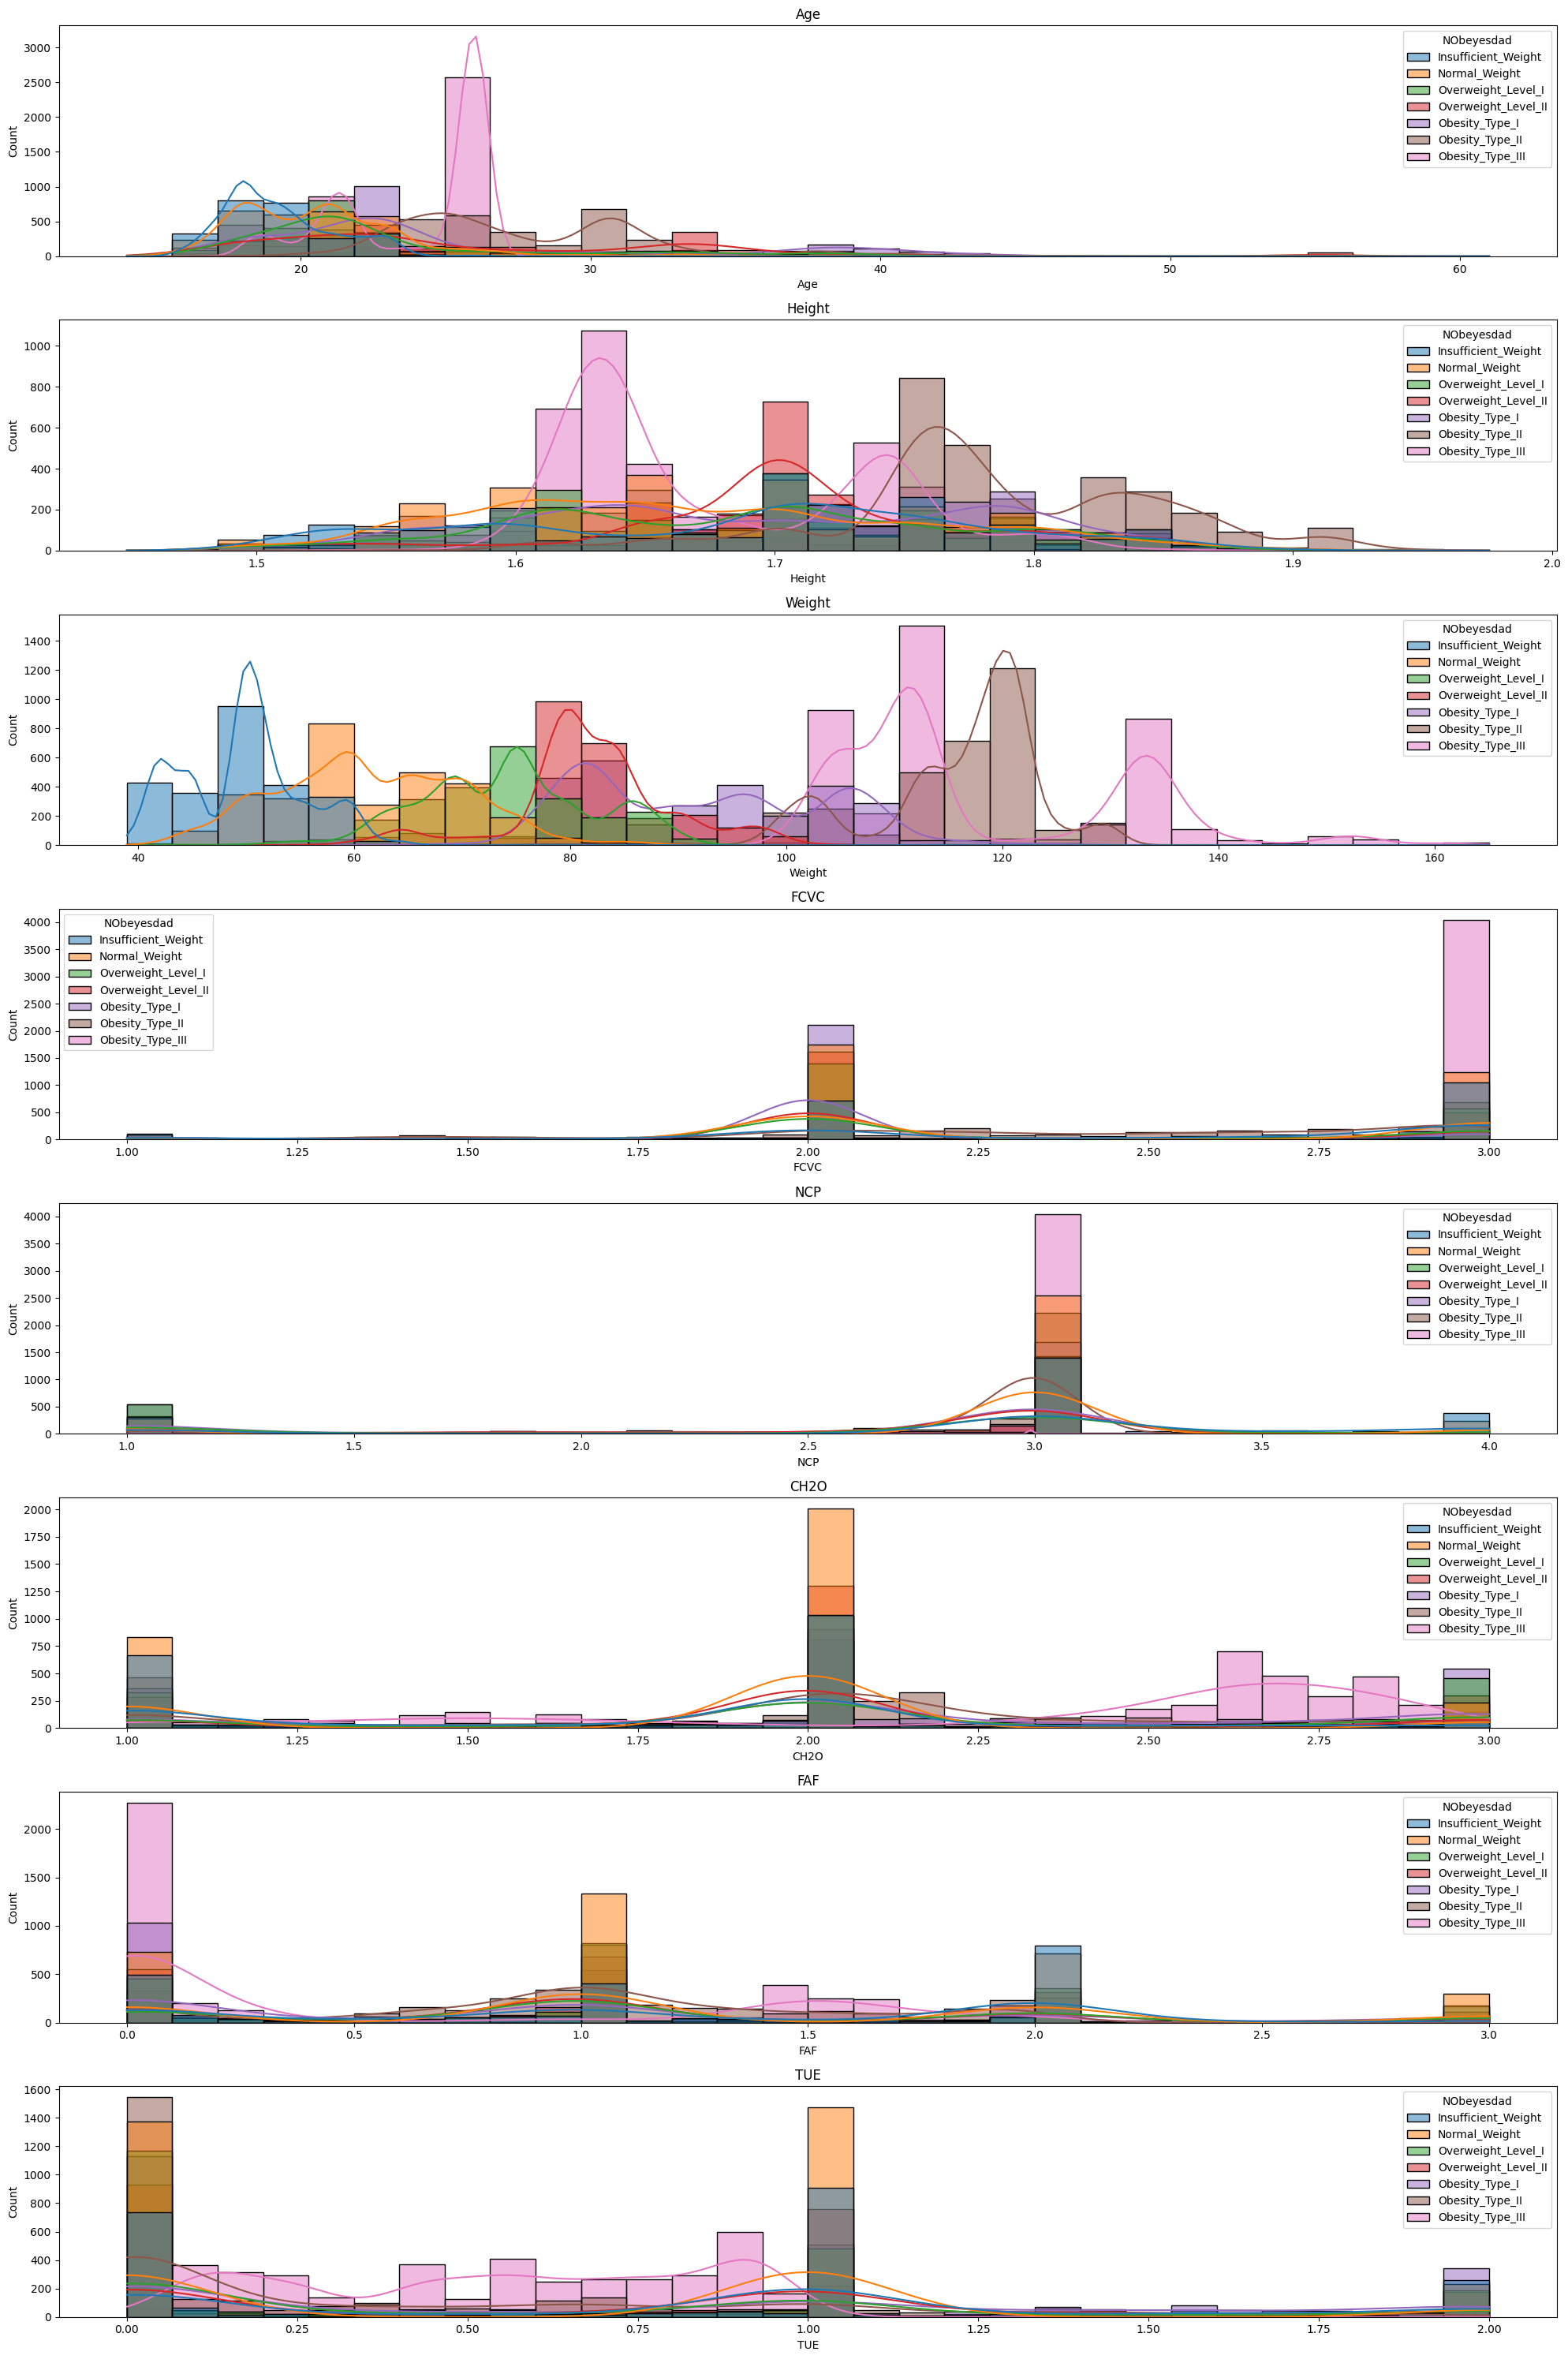

In [99]:
df = df_train.copy()

# Visualização das relações entre as variáveis numéricas
plt.figure(figsize=(20, 30))

plt.subplot(8, 1, 1)
sns.histplot(data=df, x='Age', hue='NObeyesdad', bins=30, kde=True, hue_order=category_order)
plt.title('Age')

plt.subplot(8, 1, 2)
sns.histplot(data=df, x='Height', hue='NObeyesdad', bins=30, kde=True, hue_order=category_order)
plt.title('Height')

plt.subplot(8, 1, 3)
sns.histplot(data=df, x='Weight', hue='NObeyesdad', bins=30, kde=True, hue_order=category_order)
plt.title('Weight')

plt.subplot(8, 1, 4)
sns.histplot(data=df, x='FCVC', hue='NObeyesdad', bins=30, kde=True, hue_order=category_order)
plt.title('FCVC')

plt.subplot(8, 1, 5)
sns.histplot(data=df, x='NCP', hue='NObeyesdad', bins=30, kde=True, hue_order=category_order)
plt.title('NCP')

plt.subplot(8, 1, 6)
sns.histplot(data=df, x='CH2O', hue='NObeyesdad', bins=30, kde=True, hue_order=category_order)
plt.title('CH2O')

plt.subplot(8, 1, 7)
sns.histplot(data=df, x='FAF', hue='NObeyesdad', bins=30, kde=True, hue_order=category_order)
plt.title('FAF')

plt.subplot(8, 1, 8)
sns.histplot(data=df, x='TUE', hue='NObeyesdad', bins=30, kde=True, hue_order=category_order)
plt.title('TUE')

plt.tight_layout()
plt.show()

O peso parece ser muito relevante para prever o NObeyesdad, então pode ser interessante calcular o IMC (Índice de Massa Corporal).

### Adição de uma nova variável explicativa (IMC)

In [104]:
# Função para cálculo do IMC (Índice de Massa Corporal)
def calculate_bmi(weight, height):
    height_m = height   
    bmi = weight / (height_m ** 2)
    return bmi

# Adição da coluna IMC aos dados
df['BMI'] = df.apply(lambda row: calculate_bmi(row['Weight'], row['Height']), axis=1)

# Exibir o DataFrame para verificação
print(df.head())

   id  Gender        Age    Height      Weight family_history_with_overweight  \
0   0    Male  24.443011  1.699998   81.669950                            yes   
1   1  Female  18.000000  1.560000   57.000000                            yes   
2   2  Female  18.000000  1.711460   50.165754                            yes   
3   3  Female  20.952737  1.710730  131.274851                            yes   
4   4    Male  31.641081  1.914186   93.798055                            yes   

  FAVC      FCVC       NCP        CAEC SMOKE      CH2O SCC       FAF  \
0  yes  2.000000  2.983297   Sometimes    no  2.763573  no  0.000000   
1  yes  2.000000  3.000000  Frequently    no  2.000000  no  1.000000   
2  yes  1.880534  1.411685   Sometimes    no  1.910378  no  0.866045   
3  yes  3.000000  3.000000   Sometimes    no  1.674061  no  1.467863   
4  yes  2.679664  1.971472   Sometimes    no  1.979848  no  1.967973   

        TUE       CALC                 MTRANS           NObeyesdad        BMI  


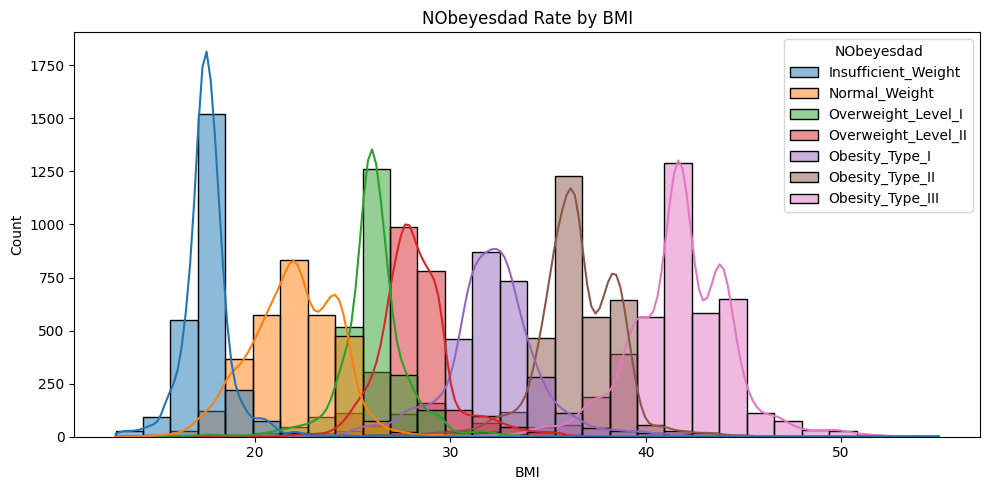

In [105]:
# Visualização das relações com a variável alvo
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x='BMI', hue='NObeyesdad', bins=30, kde=True, hue_order=category_order)
plt.title('NObeyesdad Rate by BMI')

plt.tight_layout()
plt.show()

De fato, o IMC é muito representativo para as classes de NObeyesdad.

## Treinamento do modelo

### Pré-processamento: codificação e normalização dos dados ###

In [106]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

df = df_train.copy()

# Remover a variável alvo e o identificador
X = df.drop(columns=['NObeyesdad', 'id'])

# Codificação das colunas ordinais ou booleanas
le_dict = {}
colonnes_label = [
    'Gender',
    'family_history_with_overweight',
    'FAVC',
    'CAEC',
    'SMOKE',
    'SCC',
    'CALC'
]

for col in colonnes_label:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

# Codificação one-hot para as colunas categóricas não ordinais
X = pd.get_dummies(X, columns=['MTRANS'], drop_first=True)

# Codificação do alvo (variável dependente)
y = df['NObeyesdad']
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

# Normalização com StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Separação dos dados em conjunto de treino e teste

In [45]:
from sklearn.model_selection import train_test_split

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [107]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    'RandomForest': RandomForestClassifier(),
    "XGBoost": XGBClassifier(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(max_iter=10000, solver='lbfgs'),
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(f"{name} : {scores.mean():.4f} (+/- {scores.std():.4f})")

RandomForest : 0.8985 (+/- 0.0026)
XGBoost : 0.9023 (+/- 0.0049)
SVM : 0.8617 (+/- 0.0064)
KNN : 0.7625 (+/- 0.0052)
LogisticRegression : 0.8603 (+/- 0.0046)


RandomForest: 0.8985 (+/- 0.0026)

XGBoost: 0.9023 (+/- 0.0049)

SVM: 0.8617 (+/- 0.0064)

KNN: 0.7625 (+/- 0.0052)

Regressão Logística: 0.8603 (+/- 0.0046)

O modelo mais eficaz é o **XGBoost**. Vamos tentar otimizá-lo.



### Vamos adicionar o IMC (Índice de Massa Corporal) aos dados

In [108]:
# Adição da coluna IMC aos dados de treinamento
df_with_bmi = df_train.copy()
df_with_bmi['BMI'] = df_with_bmi.apply(lambda row: row['Weight'] / (row['Height'] ** 2), axis=1)

In [109]:
# Remover a variável alvo e o identificador
X = df_with_bmi.drop(columns=['NObeyesdad', 'id'])

# Codificação das colunas ordinais ou booleanas
le_dict = {}
colonnes_label = [
    'Gender',
    'family_history_with_overweight',
    'FAVC',
    'CAEC',
    'SMOKE',
    'SCC',
    'CALC'
]

for col in colonnes_label:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

# Codificação one-hot para as colunas categóricas não ordinais
X = pd.get_dummies(X, columns=['MTRANS'], drop_first=True)

# Codificação do alvo
y = df_with_bmi['NObeyesdad']
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

# Normalização com StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Treinamento do modelo
model = XGBClassifier(random_state=42)
model.fit(X_train, y_train)
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print(f"XGBoost : {scores.mean():.4f} (+/- {scores.std():.4f})")

XGBoost : 0.9023 (+/- 0.0049)


XGBoost : 0.9023 (+/- 0.0049)

### Vamos ver quais são as features mais importantes para o XGBoost

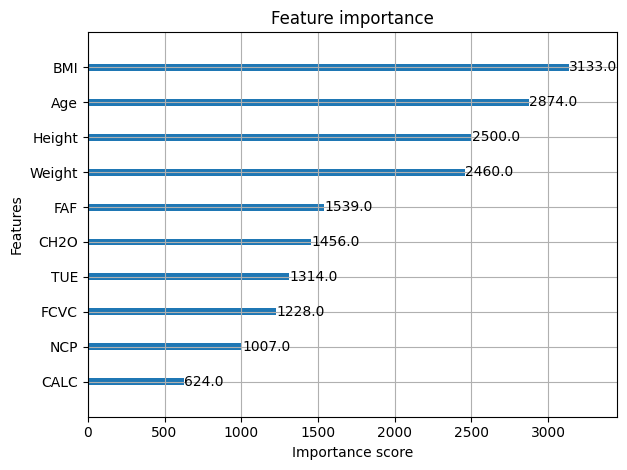

In [110]:
from xgboost import XGBClassifier, plot_importance
import matplotlib.pyplot as plt

plot_importance(model, max_num_features=10)
plt.tight_layout()
plt.show()


O IMC está em primeiro lugar na tabela, essa adição é muito relevante.

### Busca dos melhores hiperparâmetros para melhorar o desempenho do XGBoost

In [111]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.7, 1],
    'colsample_bytree': [0.7, 1]
}

grid = GridSearchCV(XGBClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print(f"Best score: {grid.best_score_:.4f}")
print(f"Best params: {grid.best_params_}")


Best score: 0.9070
Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.7}


Best score: 0.9070

Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.7}

In [62]:
best_model = XGBClassifier(
    colsample_bytree=0.7,
    learning_rate=0.1,
    max_depth=5,
    n_estimators=200,
    subsample=0.7,
    random_state=42
)
best_model.fit(X_train, y_train)
scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"XGBoost : {scores.mean():.4f} (+/- {scores.std():.4f})")

XGBoost : 0.9070 (+/- 0.0040)


Acurácia com os hiperparâmetros encontrados : 0.9070 (+/- 0.0040)

## Treinamento com 100% dos dados de treinamento e criação do arquivo de submissão

In [112]:
# Carregando os dados
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

# Cálculo do IMC nos dois conjuntos de dados
df_train['BMI'] = df_train.apply(lambda row: row['Weight'] / (row['Height'] ** 2), axis=1)
df_test['BMI'] = df_test.apply(lambda row: row['Weight'] / (row['Height'] ** 2), axis=1)

# Variáveis para codificar com LabelEncoder
colonnes_label = [
    'Gender',
    'family_history_with_overweight',
    'FAVC',
    'CAEC',
    'SMOKE',
    'SCC',
    'CALC'
]

# Codificação
le_dict = {}
for col in colonnes_label:
    le = LabelEncoder()
    df_test[col] = le.fit_transform(df_test[col])
    df_train[col] = le.transform(df_train[col])
    le_dict[col] = le

# Codificação do alvo
le_target = LabelEncoder()
y = le_target.fit_transform(df_train['NObeyesdad'])

# Preparação de X
X = df_train.drop(columns=['NObeyesdad', 'id'])
X_test = df_test.drop(columns=['id'])

# Codificação one-hot de MTRANS
X = pd.get_dummies(X, columns=['MTRANS'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['MTRANS'], drop_first=True)

# Padronização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# Retreinamento do modelo com os melhores parâmetros
final_model = XGBClassifier(
    colsample_bytree=0.7,
    learning_rate=0.1,
    max_depth=5,
    n_estimators=200,
    subsample=0.7
)
final_model.fit(X_scaled, y)

# Predições
y_pred_encoded = final_model.predict(X_test_scaled)
y_pred_labels = le_target.inverse_transform(y_pred_encoded)

# Geração da submissão
submission = pd.DataFrame({
    'id': df_test['id_original'] if 'id_original' in df_test else pd.read_csv("test.csv")['id'],
    'NObeyesdad': y_pred_labels
})

submission.to_csv("submission.csv", index=False)


### Verificação do formato do arquivo de submissão

In [113]:
submission.head()
print(submission.columns)

sample = pd.read_csv("sample_submission.csv")
print(submission.columns.equals(sample.columns))
print(submission.shape == sample.shape)    

print(len(submission) == len(df_test))


Index(['id', 'NObeyesdad'], dtype='object')
True
True
True


## Resultados no Kaggle

Acurácia :

Private score : 0.90715

Public score : 0.91257
